In [2]:
import pandas as pd
df = pd.read_csv("957ad409-c979-4e60-aa5f-b552db0307ed.tmp.")

In [3]:
df.head()

,Date,Hour,CPU_Utilization_%,GPU_Utilization_%,Active_Servers,Outside_Temperature_C,Humidity_%,Cooling_Method,Cooling_Efficiency_%,AI_Workload,Renewable_Energy_%,PUE,Energy_Consumption_kWh
0,2025-01-01,0,34,13,459,18.8,53,Air,84,Low,23,1.57,1611.0
1,2025-01-01,1,31,85,296,11.0,36,Air,80,High,74,1.52,1866.3
2,2025-01-01,2,89,63,192,24.4,60,Air,85,Medium,30,1.59,1883.0
3,2025-01-01,3,39,37,470,20.8,36,Water,87,Medium,55,1.69,1871.4
4,2025-01-01,4,25,68,354,14.0,73,Air,83,Medium,47,1.68,1785.7


In [4]:
df.tail()

,Date,Hour,CPU_Utilization_%,GPU_Utilization_%,Active_Servers,Outside_Temperature_C,Humidity_%,Cooling_Method,Cooling_Efficiency_%,AI_Workload,Renewable_Energy_%,PUE,Energy_Consumption_kWh
495,2025-01-21,15,24,59,285,29.6,61,Liquid,97,Medium,17,1.76,1683.6
496,2025-01-21,16,83,66,85,16.5,61,Air,79,Medium,86,1.46,1657.5
497,2025-01-21,17,41,96,98,21.5,25,Air,79,High,45,1.65,1752.2
498,2025-01-21,18,70,61,380,16.4,26,Liquid,98,Medium,18,1.74,1993.4
499,2025-01-21,19,91,84,258,21.1,60,Air,83,High,34,1.42,2198.1


In [5]:
df.shape

(500, 13)

In [6]:
df.columns

Index(['Date', 'Hour', 'CPU_Utilization_%', 'GPU_Utilization_%',
       'Active_Servers', 'Outside_Temperature_C', 'Humidity_%',
       'Cooling_Method', 'Cooling_Efficiency_%', 'AI_Workload',
       'Renewable_Energy_%', 'PUE', 'Energy_Consumption_kWh'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    500 non-null    object 
 1   Hour                    500 non-null    int64  
 2   CPU_Utilization_%       500 non-null    int64  
 3   GPU_Utilization_%       500 non-null    int64  
 4   Active_Servers          500 non-null    int64  
 5   Outside_Temperature_C   500 non-null    float64
 6   Humidity_%              500 non-null    int64  
 7   Cooling_Method          500 non-null    object 
 8   Cooling_Efficiency_%    500 non-null    int64  
 9   AI_Workload             500 non-null    object 
 10  Renewable_Energy_%      500 non-null    int64  
 11  PUE                     500 non-null    float64
 12  Energy_Consumption_kWh  500 non-null    float64
dtypes: float64(3), int64(7), object(3)
memory usage: 50.9+ KB


In [8]:
df.describe()

,Hour,CPU_Utilization_%,GPU_Utilization_%,Active_Servers,Outside_Temperature_C,Humidity_%,Cooling_Efficiency_%,Renewable_Energy_%,PUE,Energy_Consumption_kWh
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,11.420000,58.198000,55.000000,279.344000,26.550800,58.874000,89.230000,52.210000,1.456620,1794.948600
std,6.897736,22.160799,25.350291,123.247188,9.314134,19.205829,6.130928,22.778138,0.200169,354.215182
min,0.000000,20.000000,10.000000,80.000000,10.100000,25.000000,79.000000,10.000000,1.100000,751.500000
25%,5.000000,39.000000,33.000000,168.500000,18.775000,42.000000,83.000000,32.000000,1.290000,1529.975000
50%,11.000000,58.000000,56.000000,275.000000,26.600000,59.000000,90.000000,54.000000,1.470000,1824.900000
75%,17.000000,78.000000,76.250000,385.000000,34.725000,76.000000,94.000000,70.000000,1.620000,2055.150000
max,23.000000,95.000000,98.000000,500.000000,42.000000,90.000000,99.000000,90.000000,1.800000,2707.200000


In [9]:
df.sample(5)

,Date,Hour,CPU_Utilization_%,GPU_Utilization_%,Active_Servers,Outside_Temperature_C,Humidity_%,Cooling_Method,Cooling_Efficiency_%,AI_Workload,Renewable_Energy_%,PUE,Energy_Consumption_kWh
307,2025-01-13,19,78,72,247,28.6,36,Liquid,96,High,55,1.70,2079.6
17,2025-01-01,17,88,26,145,31.1,46,Water,91,Low,87,1.40,1461.1
414,2025-01-18,6,86,35,263,32.5,62,Air,79,Medium,80,1.45,1841.7
109,2025-01-05,13,56,96,359,15.1,81,Water,91,High,48,1.55,2189.5
21,2025-01-01,21,89,26,450,39.9,85,Air,85,Low,70,1.67,2155.5


In [10]:
#cleaning
df.isnull().sum()

Date                      0
Hour                      0
CPU_Utilization_%         0
GPU_Utilization_%         0
Active_Servers            0
Outside_Temperature_C     0
Humidity_%                0
Cooling_Method            0
Cooling_Efficiency_%      0
AI_Workload               0
Renewable_Energy_%        0
PUE                       0
Energy_Consumption_kWh    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
#feature engineering
df["Total_computation_power"] = (df["CPU_Utilization_%"] + df["GPU_Utilization_%"])

In [13]:
df["Energy_per_server"] = (df["Energy_Consumption_kWh"] / df["Active_Servers"])

In [14]:
df["cooling_load"] = (df["GPU_Utilization_%"] * df["Outside_Temperature_C"]) / 100

In [15]:
df.head()

,Date,Hour,CPU_Utilization_%,GPU_Utilization_%,Active_Servers,Outside_Temperature_C,Humidity_%,Cooling_Method,Cooling_Efficiency_%,AI_Workload,Renewable_Energy_%,PUE,Energy_Consumption_kWh,Total_computation_power,Energy_per_server,cooling_load
0,2025-01-01,0,34,13,459,18.8,53,Air,84,Low,23,1.57,1611.0,47,3.509804,2.444
1,2025-01-01,1,31,85,296,11.0,36,Air,80,High,74,1.52,1866.3,116,6.305068,9.350
2,2025-01-01,2,89,63,192,24.4,60,Air,85,Medium,30,1.59,1883.0,152,9.807292,15.372
3,2025-01-01,3,39,37,470,20.8,36,Water,87,Medium,55,1.69,1871.4,76,3.981702,7.696
4,2025-01-01,4,25,68,354,14.0,73,Air,83,Medium,47,1.68,1785.7,93,5.044350,9.520


In [16]:
df.columns

Index(['Date', 'Hour', 'CPU_Utilization_%', 'GPU_Utilization_%',
       'Active_Servers', 'Outside_Temperature_C', 'Humidity_%',
       'Cooling_Method', 'Cooling_Efficiency_%', 'AI_Workload',
       'Renewable_Energy_%', 'PUE', 'Energy_Consumption_kWh',
       'Total_computation_power', 'Energy_per_server', 'cooling_load'],
      dtype='object')

In [17]:
#covert
df["Date"] = pd.to_datetime(df["Date"])

In [18]:
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekday"] = df["Date"].dt.dayofweek

In [19]:
df.drop("Date", axis=1 , inplace=True)

In [20]:
from sklearn.preprocessing import LabelEncoder
le_cooling = LabelEncoder()
df["Cooling_Method"] = le_cooling.fit_transform(df["Cooling_Method"])

In [21]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["AI_Workload"] = le.fit_transform(df["AI_Workload"])

In [22]:
df.head()

,Hour,CPU_Utilization_%,GPU_Utilization_%,Active_Servers,Outside_Temperature_C,Humidity_%,Cooling_Method,Cooling_Efficiency_%,AI_Workload,Renewable_Energy_%,PUE,Energy_Consumption_kWh,Total_computation_power,Energy_per_server,cooling_load,month,day,weekday
0,0,34,13,459,18.8,53,0,84,1,23,1.57,1611.0,47,3.509804,2.444,1,1,2
1,1,31,85,296,11.0,36,0,80,0,74,1.52,1866.3,116,6.305068,9.350,1,1,2
2,2,89,63,192,24.4,60,0,85,2,30,1.59,1883.0,152,9.807292,15.372,1,1,2
3,3,39,37,470,20.8,36,2,87,2,55,1.69,1871.4,76,3.981702,7.696,1,1,2
4,4,25,68,354,14.0,73,0,83,2,47,1.68,1785.7,93,5.044350,9.520,1,1,2


In [23]:
#EDA
#what does the energy consumption looks like?
df["Energy_Consumption_kWh"].describe()

count     500.000000
mean     1794.948600
std       354.215182
min       751.500000
25%      1529.975000
50%      1824.900000
75%      2055.150000
max      2707.200000
Name: Energy_Consumption_kWh, dtype: float64

In [24]:
#Average energy consumption
df["Energy_Consumption_kWh"].mean()

np.float64(1794.9486)

In [25]:
#Maximum energy
df["Energy_Consumption_kWh"].max()

2707.2

In [26]:
#minimum energy
df["Energy_Consumption_kWh"].min()

751.5

In [29]:
#Avg CPU utilization
df["CPU_Utilization_%"].mean()

np.float64(58.198)

In [30]:
#Average GPU utilization
df["GPU_Utilization_%"].mean()

np.float64(55.0)

In [31]:
#Which cooling method is used the most?
#Air = 0 , Liquid = 1 ,Water = 2
df["Cooling_Method"].value_counts()

Cooling_Method
0    178
2    162
1    160
Name: count, dtype: int64

In [32]:
#Average energy consumed by AI workload
df.groupby("AI_Workload")["Energy_Consumption_kWh"].mean()

AI_Workload
0    2052.662874
1    1509.221324
2    1773.733503
Name: Energy_Consumption_kWh, dtype: float64

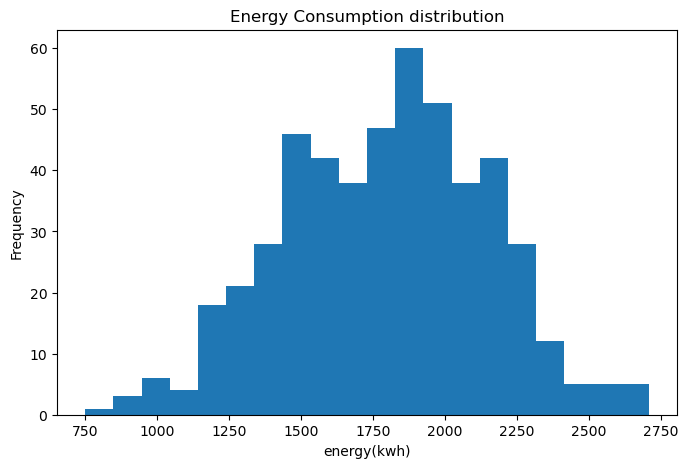

In [35]:
#Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df["Energy_Consumption_kWh"],bins=20)
plt.title("Energy Consumption distribution")
plt.xlabel("energy(kwh)")
plt.ylabel("Frequency")
plt.show()

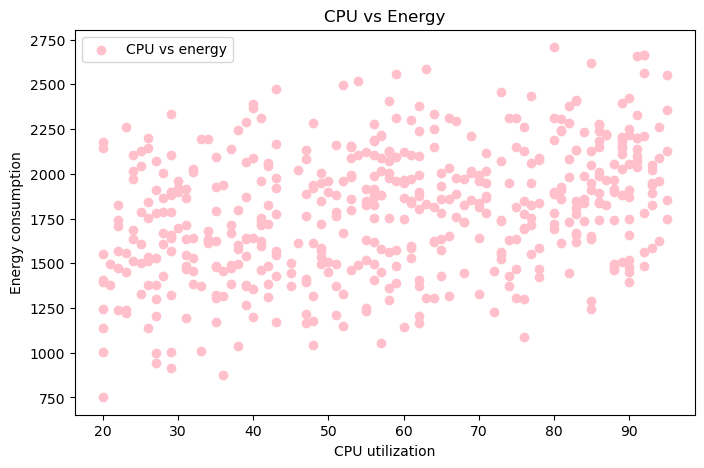

In [37]:
#CPU VS ENERGY
plt.figure(figsize=(8,5))
plt.scatter(df["CPU_Utilization_%"] , df["Energy_Consumption_kWh"], label = "CPU vs energy" , color = "Pink")
plt.title("CPU vs Energy")
plt.xlabel("CPU utilization")
plt.ylabel("Energy consumption")
plt.legend()
plt.show()

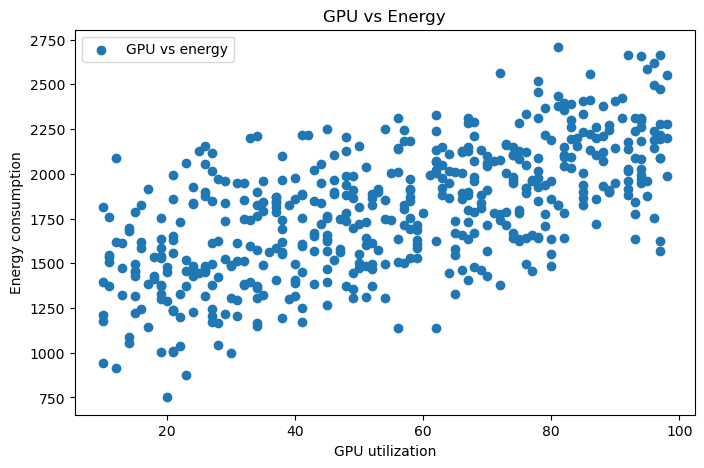

In [38]:
#GPU vs Energy
plt.figure(figsize=(8,5))
plt.scatter(df["GPU_Utilization_%"] , df["Energy_Consumption_kWh"], label = "GPU vs energy" )
plt.title("GPU vs Energy")
plt.xlabel("GPU utilization")
plt.ylabel("Energy consumption")
plt.legend()
plt.show()

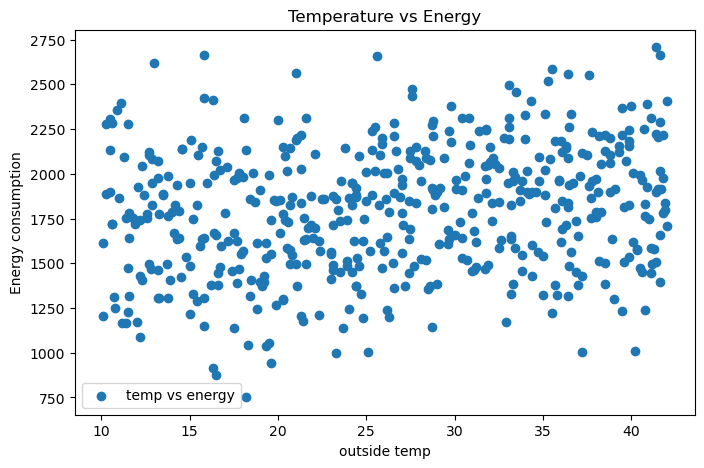

In [39]:
#Temperature vs Energy
plt.figure(figsize=(8,5))
plt.scatter(df["Outside_Temperature_C"] , df["Energy_Consumption_kWh"], label = "temp vs energy" )
plt.title("Temperature vs Energy")
plt.xlabel("outside temp")
plt.ylabel("Energy consumption")
plt.legend()
plt.show()

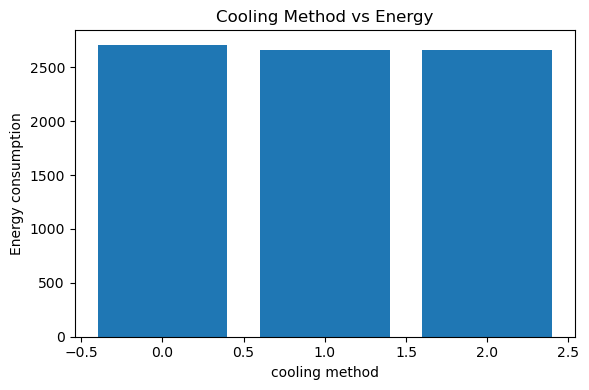

In [44]:
#Cooling Method vs Energy
plt.figure(figsize=(6,4))
plt.bar(df["Cooling_Method"] , df["Energy_Consumption_kWh"])
plt.title("Cooling Method vs Energy")
plt.xlabel("cooling method")
plt.ylabel("Energy consumption")
plt.tight_layout()
plt.show()

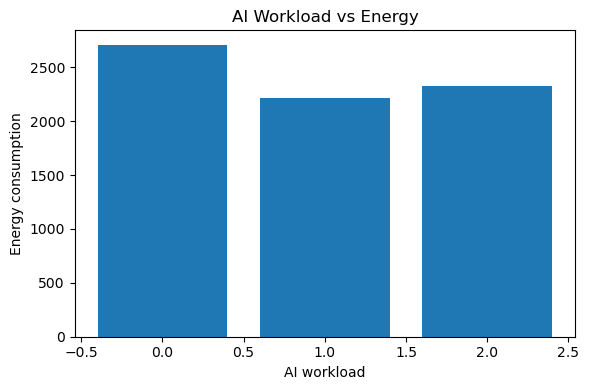

In [46]:
#AI Workload vs Energy
plt.figure(figsize=(6,4))
plt.bar(df["AI_Workload"] , df["Energy_Consumption_kWh"])
plt.title("AI Workload vs Energy")
plt.xlabel("AI workload")
plt.ylabel("Energy consumption")
plt.tight_layout()
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x = df.drop("Energy_Consumption_kWh" , axis = 1)
y = df["Energy_Consumption_kWh"]
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size = 0.2 , random_state = 42)

In [58]:
model = LinearRegression()
model.fit(x_train , y_train)
pred = model.predict(x_test)
print(pred[:10])

[1634.59029478 1464.4990093  1977.21874031 2093.22252429 1900.12915154
 1898.09693087 1178.01634042 1546.30723131 2098.39842119 1581.88310314]


In [59]:
#compare
comparison = pd.DataFrame({
    "Actual" : y_test.values,
    "Prediction" : pred})
comparison.head(10)

,Actual,Prediction
0,1641.0,1634.590295
1,1496.1,1464.499009
2,1959.4,1977.218740
3,2124.7,2093.222524
4,1914.6,1900.129152
5,1880.6,1898.096931
6,1164.5,1178.016340
7,1481.6,1546.307231
8,2094.8,2098.398421
9,1618.2,1581.883103


In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R² Score :", r2)

MAE : 24.096677683297763
MSE : 805.8866603352293
RMSE : 28.388142953268876
R² Score : 0.9924360536848423


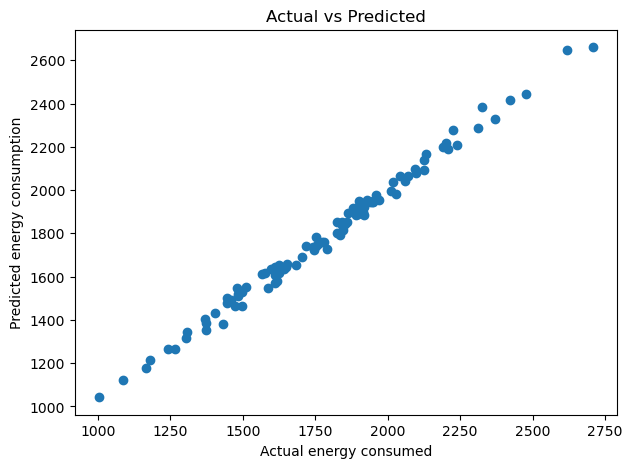

In [61]:
#Actual vs Predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred)
plt.xlabel("Actual energy consumed")
plt.ylabel("Predicted energy consumption")
plt.title("Actual vs Predicted")
plt.show()